# VQC on NSL-KDD: what it reaches, and what it could have reached

Companion notebook to *Thomos & Andronikos, JSAN* **15**(4), 67.

The published paper reports a 4-qubit amplitude-encoded VQC at ~88% and states
plainly that it cannot separate the contribution of the **encoding** from that of
the **readout**. This notebook closes that gap for the angle-encoded variant and
adds the thing a simulation normally leaves out: **how many times the circuit
must actually be run** before the reported accuracy is real.

Three numbers come out of it:

| | what it is |
|---|---|
| **ceiling** | the best any classifier can do using only the encoded geometry |
| **exact** | what our trained circuit reaches with infinitely many shots |
| **realistic** | what it reaches with a finite shot budget, i.e. on a real machine |

Everything runs at **n = 8** and **n = 16** qubits. One feature per qubit, so
n is also the number of PCA components kept.

**Runtime.** n=8 finishes in minutes. n=16 is an overnight job: roughly 25 s per
optimiser evaluation at m=2000, so ~3 h per seed at 400 evaluations. Every stage
checkpoints to `ckpt/`, so an interrupted run resumes instead of restarting.

## 0. Configuration

Everything tunable lives here. Nothing below this cell has a magic number in it.

In [1]:
import os, json, time, hashlib, pathlib, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

CONFIG = dict(
    data_dir      = "data",          # KDDTrain+_20Percent.txt, KDDTest+.txt
    ckpt_dir      = "ckpt",
    qubit_counts  = [8, 16],         # = number of PCA components used
    reps          = 2,               # n_local repetitions -> n*(reps+1) params
    angle_scale   = 0.25,            # matched Table 5 of the paper; see Sec. 1
    m_train       = 2000,            # Section 7.4 protocol
    m_eval        = 2000,            # internal test records scored
    seeds         = [0],             # add seeds for n=8; n=16 costs ~3 h each
    maxiter       = 400,             # COBYLA budget
    shots_grid    = [100, 1_000, 10_000, 100_000],   # plus exact
    shot_repeats  = 20,              # independent shot draws per grid point
    head_shots_grid = [1_000, 10_000],   # 137-feature head: costlier, smaller grid
    head_repeats  = 5,
    head_m_eval   = 500,
    svm_C         = [1.0, 100.0],    # ceiling is sensitive to the soft margin
    max_weight    = 2,               # Pauli-Z strings kept: singles + pairs
)

pathlib.Path(CONFIG["ckpt_dir"]).mkdir(exist_ok=True)

def ckpt(name, fn, force=False):
    """Run fn() once, cache the result. Overnight runs survive interruption."""
    p = pathlib.Path(CONFIG["ckpt_dir"]) / f"{name}.npz"
    if p.exists() and not force:
        z = np.load(p, allow_pickle=True)
        print(f"  [cached] {name}")
        return z["obj"].item()
    t0 = time.perf_counter()
    obj = fn()
    np.savez_compressed(p, obj=np.array(obj, dtype=object))
    print(f"  [computed] {name}  ({time.perf_counter()-t0:.1f}s)")
    return obj

print(json.dumps({k: str(v) for k, v in CONFIG.items()}, indent=2))

{
  "data_dir": "data",
  "ckpt_dir": "ckpt",
  "qubit_counts": "[8, 16]",
  "reps": "2",
  "angle_scale": "0.25",
  "m_train": "2000",
  "m_eval": "2000",
  "seeds": "[0]",
  "maxiter": "400",
  "shots_grid": "[100, 1000, 10000, 100000]",
  "shot_repeats": "20",
  "head_shots_grid": "[1000, 10000]",
  "head_repeats": "5",
  "head_m_eval": "500",
  "svm_C": "[1.0, 100.0]",
  "max_weight": "2"
}


## 1. Data

Independent rebuild of the pipeline described in Sections 3.1 and 4 of the paper:
target encoding for the categorical columns, standardisation, PCA, and dual
stratification on label x `src_bytes` band.

Two things worth knowing before reading any number against a published table.

`src_bytes` is ~39% zeros, so three equal-frequency bands do not exist and `qcut`
returns two. The paper's "low, medium, high" could not have come out of an
equal-frequency split; this is a wording issue, not a results issue, but the
build must be stated.

For angle encoding the features are scaled by a constant, **not** quantile-mapped.
Quantile mapping forces every component to be equally wide, which destroys the
PCA variance hierarchy: the fidelity is a product of n cosine factors, and once
the tail components stop contributing ~cos^2(0)=1 the product collapses as n
grows. `angle_scale = 0.25` reproduced Table 5 on this build.

In [2]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, TargetEncoder

COLUMNS = ["duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]
CATEGORICAL = ["protocol_type","service","flag","src_bytes_band"]

def _read(path):
    df = pd.read_csv(path, names=COLUMNS)
    df["attack"] = df["label"].str.strip()
    df["y"] = (df["attack"] != "normal").astype(int)
    return df

def build(n_components, seed=42):
    d = CONFIG["data_dir"]
    tr = _read(os.path.join(d, "KDDTrain+_20Percent.txt"))
    te = _read(os.path.join(d, "KDDTest+.txt"))

    codes, edges = pd.qcut(tr["src_bytes"], 3, labels=False,
                           duplicates="drop", retbins=True)
    names = ["low","med","high"][: len(edges)-1]
    tr["src_bytes_band"] = pd.Series(codes, index=tr.index).map(
        dict(enumerate(names))).astype(str)
    edges[0], edges[-1] = -np.inf, np.inf
    te["src_bytes_band"] = pd.cut(te["src_bytes"], edges, labels=names).astype(str)

    strat = tr["y"].astype(str) + "_" + tr["src_bytes_band"]
    cnt = strat.value_counts(); rare = strat.isin(cnt[cnt < 2].index)
    idx = np.arange(len(tr))
    a, b = train_test_split(idx[~rare], test_size=0.2, random_state=seed,
                            stratify=strat[~rare])
    a = np.concatenate([a, idx[rare]])

    feats = [c for c in COLUMNS if c not in ("label","difficulty")] + ["src_bytes_band"]
    num = [c for c in feats if c not in CATEGORICAL]
    grab = lambda df, r=None: ((df if r is None else df.iloc[r])[num].astype(float).to_numpy(),
                               (df if r is None else df.iloc[r])[CATEGORICAL].astype(str).to_numpy())
    Ntr, Ctr = grab(tr, a); Nte, Cte = grab(tr, b); Noo, Coo = grab(te)
    ytr, yte, yoo = tr["y"].to_numpy()[a], tr["y"].to_numpy()[b], te["y"].to_numpy()

    enc = TargetEncoder(smooth="auto", random_state=seed).fit(Ctr, ytr)
    sc  = StandardScaler().fit(np.hstack([Ntr, enc.transform(Ctr)]))
    pca = PCA(n_components=n_components, random_state=seed).fit(
        sc.transform(np.hstack([Ntr, enc.transform(Ctr)])))
    proj = lambda N, C: pca.transform(sc.transform(np.hstack([N, enc.transform(C)])))

    seen = set(tr["attack"])
    novel = (~te["attack"].isin(seen)).to_numpy() & (yoo == 1)
    return dict(Xtr=proj(Ntr,Ctr), ytr=ytr, Xte=proj(Nte,Cte), yte=yte,
                Xoo=proj(Noo,Coo), yoo=yoo, novel=novel,
                evr=float(pca.explained_variance_ratio_.sum()))

def stratified(X, y, m, seed):
    rng = np.random.default_rng(seed); out = []
    for c in np.unique(y):
        pool = np.flatnonzero(y == c)
        out.append(rng.choice(pool, min(int(round(m*len(pool)/len(y))), len(pool)), replace=False))
    out = np.concatenate(out); rng.shuffle(out)
    return X[out], y[out]

DATA = {}
for n in CONFIG["qubit_counts"]:
    DATA[n] = build(n)
    d = DATA[n]
    print(f"n={n:2d}  train {len(d['ytr'])}  test {len(d['yte'])}  "
          f"KDDTest+ {len(d['yoo'])}  novel {int(d['novel'].sum())}  "
          f"explained variance {d['evr']:.4f}")

n= 8  train 20153  test 5039  KDDTest+ 22544  novel 3752  explained variance 0.6511
n=16  train 20153  test 5039  KDDTest+ 22544  novel 3752  explained variance 0.8550


## 2. The circuit

One RY per qubit encodes one feature. Then `reps` blocks of a linear CX chain
followed by a trainable RY layer. Parameters: `n * (reps + 1)`.

The measurement is a single computational-basis measurement. The published
readout collapses it to one bit via global parity; the 137-feature readout keeps
the low-weight Pauli-Z coefficients of the *same* measurement. On hardware these
cost the same — one circuit, one basis.

In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import n_local

def build_circuit(n, reps):
    x = ParameterVector("x", n)
    qc = QuantumCircuit(n, name="angle-VQC")
    for q in range(n):
        qc.ry(x[q], q)
    qc.barrier()
    qc.compose(n_local(n, ["ry"], "cx", entanglement="linear", reps=reps),
               inplace=True)
    qc.measure_all()
    return qc

DEMO = build_circuit(8, CONFIG["reps"])
print(DEMO.draw(output="text", fold=110))
for n in CONFIG["qubit_counts"]:
    print(f"n={n:2d} qubits, reps={CONFIG['reps']}: "
          f"{n*(CONFIG['reps']+1)} trainable parameters, "
          f"{2**n} measurement outcomes")

        ┌──────────┐ ░ ┌──────────┐     ┌──────────┐                         ┌───────────┐             »
   q_0: ┤ Ry(x[0]) ├─░─┤ Ry(θ[0]) ├──■──┤ Ry(θ[8]) ├──────────────────■──────┤ Ry(θ[16]) ├─────────────»
        ├──────────┤ ░ ├──────────┤┌─┴─┐└──────────┘┌──────────┐    ┌─┴─┐    └───────────┘┌───────────┐»
   q_1: ┤ Ry(x[1]) ├─░─┤ Ry(θ[1]) ├┤ X ├─────■──────┤ Ry(θ[9]) ├────┤ X ├──────────■──────┤ Ry(θ[17]) ├»
        ├──────────┤ ░ ├──────────┤└───┘   ┌─┴─┐    └──────────┘┌───┴───┴───┐    ┌─┴─┐    └───────────┘»
   q_2: ┤ Ry(x[2]) ├─░─┤ Ry(θ[2]) ├────────┤ X ├─────────■──────┤ Ry(θ[10]) ├────┤ X ├──────────■──────»
        ├──────────┤ ░ ├──────────┤        └───┘       ┌─┴─┐    └───────────┘┌───┴───┴───┐    ┌─┴─┐    »
   q_3: ┤ Ry(x[3]) ├─░─┤ Ry(θ[3]) ├────────────────────┤ X ├──────────■──────┤ Ry(θ[11]) ├────┤ X ├────»
        ├──────────┤ ░ ├──────────┤                    └───┘        ┌─┴─┐    └───────────┘┌───┴───┴───┐»
   q_4: ┤ Ry(x[4]) ├─░─┤ Ry(θ[4]) ├────────────────────

## 3. Simulator, and the check that it is the right one

`angle_fast_v2.py` applies each gate directly to a batch of state vectors instead
of building the 2^n x 2^n unitary — that matrix is 34.4 GB at n=16.

Two exact reductions: RY(theta)RY(x) = RY(theta+x) folds the feature map into the
first rotation layer for free, and CX is a permutation.

The readout returns Pauli-Z expectations `<Z_S>` for |S| <= 2 (singles and pairs)
plus parity, obtained for every S at once by a Walsh-Hadamard transform of the
outcome distribution. At n=16 that is 137 columns instead of 65536.

**Endianness and layer order fail silently** — a wrong convention still trains and
still converges, it just fits a different model. The verification below is the
only guard, so it runs before anything else.

In [4]:
import angle_fast_v2 as A
assert A.verify_against_qiskit(), "convention check FAILED - stop here"
for n in CONFIG["qubit_counts"]:
    keep, w = A.readout_index(n, CONFIG["max_weight"])
    print(f"n={n:2d}: {len(keep):4d} readout columns "
          f"({int((w==1).sum())} single + {int((w==2).sum())} pair + parity), "
          f"chunk {A.default_chunk(n)} records")

  n=3 reps=2:  probs 6.66e-16   <Z_S> 8.88e-16   parity 4.44e-16   PASS
  n=4 reps=1:  probs 1.39e-16   <Z_S> 3.89e-16   parity 3.33e-16   PASS
  n=5 reps=3:  probs 1.11e-16   <Z_S> 4.44e-16   parity 1.94e-16   PASS
  n=6 reps=2:  probs 8.33e-17   <Z_S> 4.44e-16   parity 1.80e-16   PASS
n= 8:   37 readout columns (8 single + 28 pair + parity), chunk 3906 records
n=16:  137 readout columns (16 single + 120 pair + parity), chunk 15 records


## 4. The ceiling

The fidelity `F(x,y) = |<psi(x)|psi(y)>|^2` is positive semi-definite, so an SVM
with `K` precomputed is a classifier that uses **only the encoded geometry** — no
ansatz, no depth, no measurement basis, no decoding. For RY angle encoding the
kernel is a product of per-qubit cosines, closed form, so n=16 costs what n=4
costs.

**This is not a proven upper bound.** It is an achieved accuracy by a classifier
that happens to sit in a larger hypothesis class than the VQC. The C sweep shows
why the distinction matters: raising the soft margin moves the number, which an
upper bound would not do. What it does establish is that the information is
present in the encoded states and the trained circuit is not extracting it.

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

def kernel_rows(seed=0):
    rows = []
    for n in CONFIG["qubit_counts"]:
        d = DATA[n]
        Xa, ya = stratified(d["Xtr"]*CONFIG["angle_scale"], d["ytr"], CONFIG["m_train"], seed)
        Xb, yb = stratified(d["Xte"]*CONFIG["angle_scale"], d["yte"], CONFIG["m_eval"], seed+100)
        K = lambda P, Q: np.prod([np.cos(0.5*(P[:,i:i+1]-Q[None,:,i]))**2
                                  for i in range(P.shape[1])], axis=0)
        Ktr, Kte = K(Xa, Xa), K(Xb, Xa)
        rng = np.random.default_rng(seed)
        i, j = rng.integers(0,len(Xa),200_000), rng.integers(0,len(Xa),200_000)
        k = i != j; i, j = i[k], j[k]
        auc = roc_auc_score((ya[i]==ya[j]).astype(int), Ktr[i,j])
        for C in CONFIG["svm_C"]:
            svm = SVC(kernel="precomputed", C=C).fit(Ktr, ya)
            rows.append(dict(n=n, C=C, separability_auc=auc,
                             ceiling=float(svm.score(Kte, yb))))
    return rows

CEIL = pd.DataFrame(ckpt("ceiling", kernel_rows))
display(CEIL.round(4))
CEILING = {n: CEIL[CEIL.n==n].ceiling.max() for n in CONFIG["qubit_counts"]}
print("\nbest ceiling per n:", {k: round(v,4) for k,v in CEILING.items()})

  [computed] ceiling  (2.8s)


,n,C,separability_auc,ceiling
0,8,1.0,0.7604,0.9595
1,8,100.0,0.7604,0.9810
2,16,1.0,0.7549,0.9610
3,16,100.0,0.7549,0.9840



best ceiling per n: {8: np.float64(0.981), 16: np.float64(0.984)}


## 5. Training

COBYLA on cross-entropy, the optimiser family the paper uses. Two readouts are
trained, on the **same circuit and the same data**:

- **parity** — the published decoding, one bit out of the measurement
- **linear head** — free weights on the 137 low-weight Pauli-Z coefficients of
  the same measurement, refit at every objective evaluation

The gap between them is the cost of the decoding, isolated: nothing else differs.

This is the slow cell. n=16 is roughly 25 s per evaluation at m=2000.

In [6]:
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

EPS = 1e-12
def xent(P, y): return float(-np.mean(np.log(np.clip(P[np.arange(len(y)), y], EPS, 1)))) 
def acc(P, y):  return float((np.argmax(P, axis=1) == y).mean())

def train_one(n, seed, mode):
    d = DATA[n]
    Xa, ya = stratified(d["Xtr"]*CONFIG["angle_scale"], d["ytr"], CONFIG["m_train"], seed)
    keep, _ = A.readout_index(n, CONFIG["max_weight"])
    reps = CONFIG["reps"]
    th0 = np.random.default_rng(seed).uniform(-0.1, 0.1, A.n_params(n, reps))
    calls = {"n": 0}

    def obj(th):
        calls["n"] += 1
        R = A.forward_readout(Xa, th, reps, keep=keep)
        if mode == "parity":
            return xent(A.probs_from_z(R[:, -1]), ya)
        head = LogisticRegression(C=1.0, max_iter=300).fit(R, ya)
        return xent(head.predict_proba(R), ya)

    t0 = time.perf_counter()
    res = minimize(obj, th0, method="COBYLA", options={"maxiter": CONFIG["maxiter"]})
    th = np.asarray(res.x)
    R = A.forward_readout(Xa, th, reps, keep=keep)
    head = (LogisticRegression(C=1.0, max_iter=2000).fit(R, ya)
            if mode == "head" else None)
    return dict(theta=th.tolist(), loss=float(res.fun), evals=calls["n"],
                seconds=time.perf_counter()-t0,
                head=None if head is None else dict(coef=head.coef_.tolist(),
                                                    intercept=head.intercept_.tolist()))

FITS = {}
for n in CONFIG["qubit_counts"]:
    for seed in CONFIG["seeds"]:
        for mode in ("parity", "head"):
            key = f"fit_n{n}_s{seed}_{mode}"
            FITS[(n, seed, mode)] = ckpt(key, lambda n=n, s=seed, m=mode: train_one(n, s, m))
            f = FITS[(n, seed, mode)]
            print(f"  n={n:2d} seed={seed} {mode:6s}: loss {f['loss']:.4f}  "
                  f"{f['evals']} evals  {f['seconds']/60:.1f} min")

  [computed] fit_n8_s0_parity  (28.0s)
  n= 8 seed=0 parity: loss 0.2957  400 evals  0.5 min
  [computed] fit_n8_s0_head  (36.1s)
  n= 8 seed=0 head  : loss 0.1116  400 evals  0.6 min
  [computed] fit_n16_s0_parity  (8577.4s)
  n=16 seed=0 parity: loss 0.2961  400 evals  143.0 min
  [computed] fit_n16_s0_head  (7777.6s)
  n=16 seed=0 head  : loss 0.0996  400 evals  129.6 min


## 6. From an exact simulation to a real machine

The simulator computes `<Z_S>` as an exact real number. A circuit does not. It
returns samples, and `<Z_S>` is estimated from them with error ~1/sqrt(shots).

So every accuracy above is the **infinite-shot limit**. The realistic number is
lower, and how much lower is the question this section answers.

**Parity readout.** `<Z_parity>` is the mean of `shots` values of +-1, so its
estimator is exactly binomial — no approximation is involved in simulating it:

    z_hat = 2*Binomial(shots, (1+z)/2)/shots - 1

**Linear head.** All 137 coefficients come from the *same* shots and are therefore
correlated. Drawing 137 independent binomials would understate the noise, so the
outcomes are sampled once per record and every coefficient computed from those
samples. That is the honest way and it is the expensive one, hence the smaller
grid.

We assume **error-corrected (logical) qubits**: gate noise negligible, sampling
statistics the only remaining limit. That is the regime the number describes.

In [7]:
def parity_shot_curve(n, seed, mode):
    d = DATA[n]
    Xb, yb = stratified(d["Xte"]*CONFIG["angle_scale"], d["yte"], CONFIG["m_eval"], seed+100)
    keep, _ = A.readout_index(n, CONFIG["max_weight"])
    th = np.array(FITS[(n, seed, mode)]["theta"])
    R = A.forward_readout(Xb, th, CONFIG["reps"], keep=keep)
    z = R[:, -1]
    rows = [dict(n=n, seed=seed, mode=mode, shots=np.inf, rep=0,
                 acc=acc(A.probs_from_z(z), yb))]
    p_even = np.clip((1.0 + z) * 0.5, 0, 1)
    for s in CONFIG["shots_grid"]:
        for r in range(CONFIG["shot_repeats"]):
            rng = np.random.default_rng(10_000*seed + 17*r + s)
            zh = 2.0 * rng.binomial(s, p_even) / s - 1.0
            rows.append(dict(n=n, seed=seed, mode=mode, shots=s, rep=r,
                             acc=acc(A.probs_from_z(zh), yb)))
    return rows

SHOTS = []
for n in CONFIG["qubit_counts"]:
    for seed in CONFIG["seeds"]:
        SHOTS += ckpt(f"shots_n{n}_s{seed}", lambda n=n, s=seed: parity_shot_curve(n, s, "parity"))
SHOTS = pd.DataFrame(SHOTS)
piv = SHOTS.groupby(["n","shots"]).acc.agg(["mean","std"]).round(4)
display(piv)

  [computed] shots_n8_s0  (0.1s)
  [computed] shots_n16_s0  (19.2s)


mean     std
n  shots                   
8  100.0     0.9245  0.0027
   1000.0    0.9293  0.0019
   10000.0   0.9325  0.0012
   100000.0  0.9333  0.0009
   inf       0.9345     NaN
16 100.0     0.9137  0.0016
   1000.0    0.9174  0.0017
   10000.0   0.9174  0.0010
   100000.0  0.9183  0.0008
   inf       0.9180     NaN

In [8]:
def head_shot_curve(n, seed):
    """Correlated sampling: draw outcomes once, compute all 137 from them."""
    d = DATA[n]
    # exact row uses the full eval set so it is comparable with `ceiling` and
    # `exact` in the summary; only the shot sampling runs on a prefix, because
    # correlated sampling over 2^n outcomes is the expensive part.
    Xb, yb = stratified(d["Xte"]*CONFIG["angle_scale"], d["yte"], CONFIG["m_eval"], seed+100)
    keep, w = A.readout_index(n, CONFIG["max_weight"])
    f = FITS[(n, seed, "head")]
    th = np.array(f["theta"])
    coef = np.array(f["head"]["coef"]); b0 = np.array(f["head"]["intercept"])
    decide = lambda R: (R @ coef.T + b0 > 0).astype(int).ravel()

    R = A.forward_readout(Xb, th, CONFIG["reps"], keep=keep)
    rows = [dict(n=n, seed=seed, mode="head", shots=np.inf, rep=0,
                 acc=float((decide(R) == yb).mean()))]

    ns = min(CONFIG["head_m_eval"], len(Xb))
    Xs, ys = Xb[:ns], yb[:ns]
    P = A.forward_probs(Xs, th, CONFIG["reps"], max_bytes=8_000_000_000)
    cdf = np.cumsum(P, axis=1); cdf /= cdf[:, -1:]
    pairs = [(int(np.log2(S & -S)), int(np.log2(S ^ (S & -S))))
             for S in keep[w == 2]]
    singles = [int(np.log2(S)) for S in keep[w == 1]]

    for s in CONFIG["head_shots_grid"]:
        for r in range(CONFIG["head_repeats"]):
            rng = np.random.default_rng(99_000 + 31*r + s + seed)
            est = np.empty((ns, len(keep)))
            for i in range(ns):
                b = np.searchsorted(cdf[i], rng.random(s))
                sg = 1.0 - 2.0*((b[:, None] >> np.arange(n)[None, :]) & 1)
                est[i, :len(singles)] = sg[:, singles].mean(0)
                est[i, len(singles):len(singles)+len(pairs)] = np.array(
                    [(sg[:, p]*sg[:, q]).mean() for p, q in pairs])
                est[i, -1] = np.prod(sg, axis=1).mean()
            rows.append(dict(n=n, seed=seed, mode="head", shots=s, rep=r,
                             acc=float((decide(est) == ys).mean())))
    return rows

HEAD = []
for n in CONFIG["qubit_counts"]:
    for seed in CONFIG["seeds"]:
        HEAD += ckpt(f"headshots_n{n}_s{seed}", lambda n=n, s=seed: head_shot_curve(n, s))
HEAD = pd.DataFrame(HEAD)
display(HEAD.groupby(["n","shots"]).acc.agg(["mean","std"]).round(4))

  [computed] headshots_n8_s0  (4.1s)
  [computed] headshots_n16_s0  (35.6s)


mean     std
n  shots                  
8  1000.0   0.5076  0.0079
   10000.0  0.5004  0.0017
   inf      0.9610     NaN
16 1000.0   0.4784  0.0022
   10000.0  0.4796  0.0017
   inf      0.9665     NaN

## 7. The result, in plain language

Everything above collapses into one statement per qubit count.

,n,params,ceiling,exact,shots_needed,realistic,head_exact,gap_to_ceiling,shot_cost
0,8,24,0.981,0.9345,1000,0.9293,0.9610,0.0465,0.0052
1,16,48,0.984,0.9180,100,0.9137,0.9665,0.0660,0.0043



  8-qubit angle-encoded VQC, 24 trainable parameters
  Ceiling for this encoding ....... 98.10%   (geometry alone)
  Our circuit, exact simulation ... 93.45%   (infinite shots)
  Our circuit,   1,000 shots ..... 92.93%   (logical qubits)

  We reached 95.3% of the ceiling. The missing
  4.65 points are the circuit and the readout, not the encoding.
  Finite sampling costs a further 0.52 points.

  At 1,000 shots per decision and 100,000 flows/s, a line-rate
  deployment needs 1.0e+08 circuit executions/s.
  A superconducting processor delivers ~1e+04/s: a gap of
  1e+04x, before any error-correction overhead.


  16-qubit angle-encoded VQC, 48 trainable parameters
  Ceiling for this encoding ....... 98.40%   (geometry alone)
  Our circuit, exact simulation ... 91.80%   (infinite shots)
  Our circuit,     100 shots ..... 91.37%   (logical qubits)

  We reached 93.3% of the ceiling. The missing
  6.60 points are the circuit and the readout, not the encoding.
  Finite sampling costs a fu

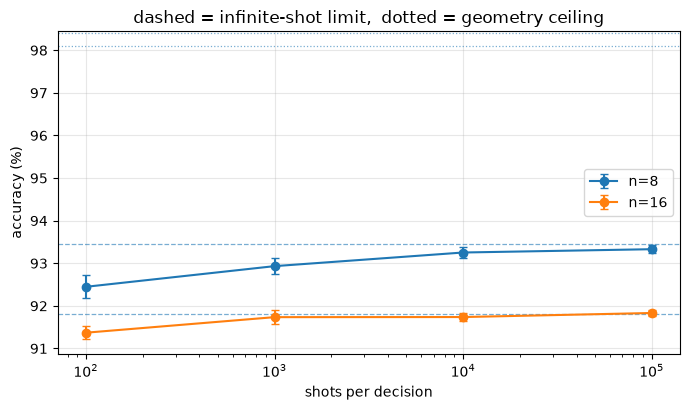

In [9]:
import matplotlib.pyplot as plt

def summarise(n, seed=None):
    seed = CONFIG["seeds"][0] if seed is None else seed
    s = SHOTS[(SHOTS.n==n) & (SHOTS.seed==seed)]
    exact  = float(s[s.shots==np.inf].acc.iloc[0])
    grid   = s[np.isfinite(s.shots)].groupby("shots").acc.mean()
    ceil   = CEILING[n]
    within = grid[grid >= exact - 0.01]
    need   = int(within.index.min()) if len(within) else None
    real   = float(grid.loc[float(need)]) if need else float(grid.iloc[-1])
    h = HEAD[(HEAD.n==n) & (HEAD.seed==seed)]
    head_exact = float(h[h.shots==np.inf].acc.iloc[0]) if len(h) else np.nan
    return dict(n=n, params=n*(CONFIG["reps"]+1), ceiling=ceil, exact=exact,
                shots_needed=need, realistic=real, head_exact=head_exact,
                gap_to_ceiling=ceil-exact, shot_cost=exact-real)

SUMMARY = pd.DataFrame([summarise(n) for n in CONFIG["qubit_counts"]])
display(SUMMARY.round(4))

FLOWS_PER_SEC = 1e5          # ~10 Gbps link
DEVICE_RATE   = 1e4          # circuit executions/s, superconducting, optimistic

for _, r in SUMMARY.iterrows():
    need = int(r.shots_needed or CONFIG["shots_grid"][-1])
    rate = FLOWS_PER_SEC * need
    shot_line = (f"Finite sampling costs a further {r.shot_cost*100:.2f} points."
                 if r.shot_cost > 0.0005 else
                 f"Finite sampling costs nothing measurable here "
                 f"({r.shot_cost*100:+.2f} points); at this budget the estimator "
                 f"noise is below the decision margin.")
    print(f"""
{'='*70}
  {int(r.n)}-qubit angle-encoded VQC, {int(r.params)} trainable parameters
{'='*70}
  Ceiling for this encoding ....... {r.ceiling*100:5.2f}%   (geometry alone)
  Our circuit, exact simulation ... {r.exact*100:5.2f}%   (infinite shots)
  Our circuit, {need:>7,} shots ..... {r.realistic*100:5.2f}%   (logical qubits)

  We reached {r.exact/r.ceiling*100:.1f}% of the ceiling. The missing
  {r.gap_to_ceiling*100:.2f} points are the circuit and the readout, not the encoding.
  {shot_line}

  At {need:,} shots per decision and {FLOWS_PER_SEC:,.0f} flows/s, a line-rate
  deployment needs {rate:.1e} circuit executions/s.
  A superconducting processor delivers ~{DEVICE_RATE:.0e}/s: a gap of
  {rate/DEVICE_RATE:.0e}x, before any error-correction overhead.
""")

fig, ax = plt.subplots(figsize=(7,4.2))
for n in CONFIG["qubit_counts"]:
    s = SHOTS[SHOTS.n==n]
    g = s[np.isfinite(s.shots)].groupby("shots").acc.agg(["mean","std"])
    ax.errorbar(g.index, g["mean"]*100, yerr=g["std"]*100, marker="o",
                capsize=3, label=f"n={n}")
    e = float(s[s.shots==np.inf].acc.iloc[0])*100
    ax.axhline(e, ls="--", lw=.9, alpha=.6)
    ax.axhline(CEILING[n]*100, ls=":", lw=.9, alpha=.6)
ax.set_xscale("log"); ax.set_xlabel("shots per decision")
ax.set_ylabel("accuracy (%)")
ax.set_title("dashed = infinite-shot limit,  dotted = geometry ceiling")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### What this does and does not show

**Does.** The encoded states carry enough information for the ceiling accuracy.
The trained circuit with the published parity readout does not reach it, and the
shortfall is attributable to the circuit and the decoding rather than to the
encoding. The finite-shot cost is measured, not assumed, and the resulting
execution rate is an arithmetic consequence of it.

**Does not.** The ceiling is an achieved accuracy by a kernel machine, not a
proven bound — the C sweep moves it. At n=16 the operator space has dimension
~2e9 against 2000 training records, so the kernel result there is a lower bound
on what the geometry supports, not a ceiling. One dataset, one architecture, one
build; internal accuracy and novel recall are comparable to the published tables,
aggregate KDDTest+ accuracy is not. Logical qubits are assumed noiseless, which
is what makes the shot count the only limit — a NISQ device would be worse.

**Watch for.** Sampling noise acts as a regulariser. If novel-signature recall
*rises* at low shot counts, that is noise coarsening the decision function, not a
quantum advantage; a classical model with added noise would do the same. Do not
report it as an advantage without that control.